### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
house_data = pd.read_csv("data.csv")


In [3]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
house_data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
price_column = 'price'

# Check how many zeros before dropping
print(f"Before dropping: {len(house_data)} rows")
print(f"Zero prices: {(house_data[price_column] == 0).sum()} rows")
print(f"Percentage zero: {(house_data[price_column] == 0).mean() * 100:.2f}%")

house_data = house_data[house_data[price_column] != 0]

Before dropping: 4600 rows
Zero prices: 49 rows
Percentage zero: 1.07%


In [6]:
for column in house_data.columns:
    print(f"Unique values in {column}: {house_data[column].unique()} \n")

Unique values in date: ['2014-05-02 00:00:00' '2014-05-03 00:00:00' '2014-05-04 00:00:00'
 '2014-05-05 00:00:00' '2014-05-06 00:00:00' '2014-05-07 00:00:00'
 '2014-05-08 00:00:00' '2014-05-09 00:00:00' '2014-05-10 00:00:00'
 '2014-05-11 00:00:00' '2014-05-12 00:00:00' '2014-05-13 00:00:00'
 '2014-05-14 00:00:00' '2014-05-15 00:00:00' '2014-05-16 00:00:00'
 '2014-05-17 00:00:00' '2014-05-18 00:00:00' '2014-05-19 00:00:00'
 '2014-05-20 00:00:00' '2014-05-21 00:00:00' '2014-05-22 00:00:00'
 '2014-05-23 00:00:00' '2014-05-24 00:00:00' '2014-05-25 00:00:00'
 '2014-05-26 00:00:00' '2014-05-27 00:00:00' '2014-05-28 00:00:00'
 '2014-05-29 00:00:00' '2014-05-30 00:00:00' '2014-05-31 00:00:00'
 '2014-06-01 00:00:00' '2014-06-02 00:00:00' '2014-06-03 00:00:00'
 '2014-06-04 00:00:00' '2014-06-05 00:00:00' '2014-06-06 00:00:00'
 '2014-06-07 00:00:00' '2014-06-08 00:00:00' '2014-06-09 00:00:00'
 '2014-06-10 00:00:00' '2014-06-11 00:00:00' '2014-06-12 00:00:00'
 '2014-06-13 00:00:00' '2014-06-14 00:0

In [7]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder

KeyboardInterrupt: 

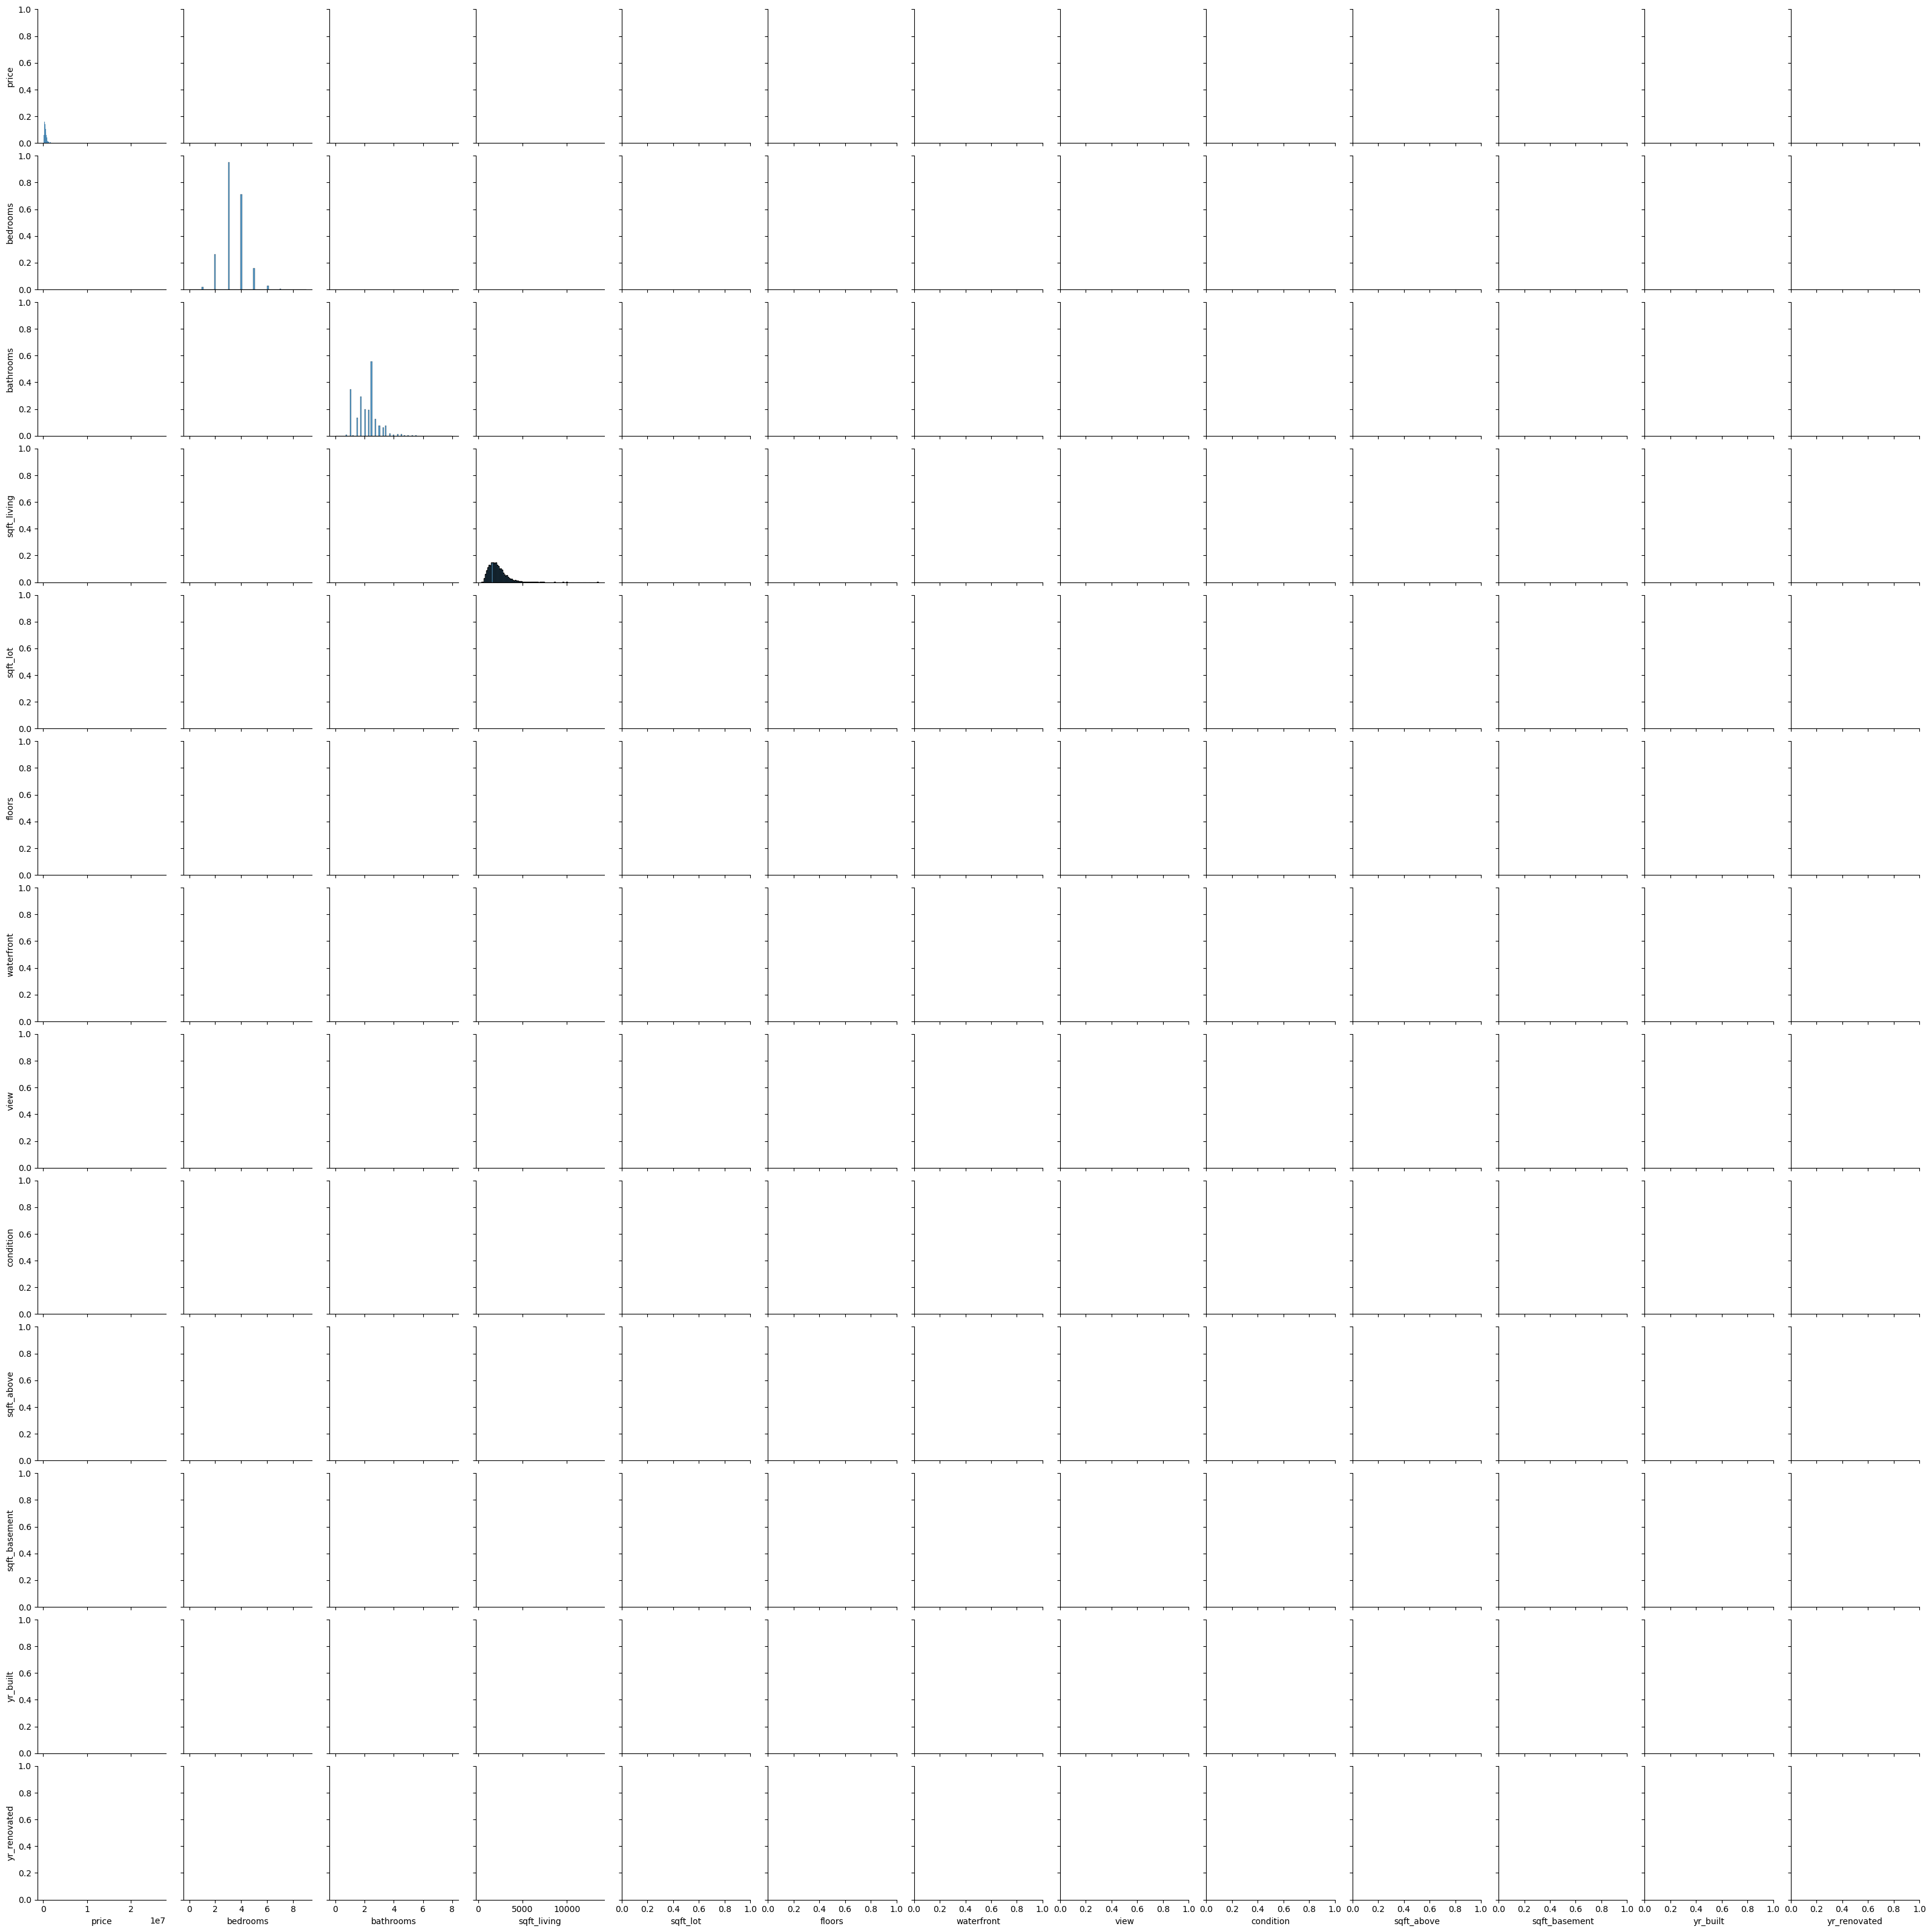

In [10]:
sns.pairplot(house_data)

In [8]:
house_data.corr(numeric_only=True)["price"].sort_values(ascending=False)

price            1.000000
sqft_living      0.445494
sqft_above       0.380661
bathrooms        0.341126
view             0.242587
sqft_basement    0.217782
bedrooms         0.210228
floors           0.152758
waterfront       0.150083
sqft_lot         0.051347
condition        0.038892
yr_built         0.021757
yr_renovated    -0.029034
Name: price, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import PowerTransformer, RobustScaler, FunctionTransformer

In [10]:
X = house_data.drop(columns=["price", "street", "country"], axis=1)
y = house_data["price"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class BasementTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["has_basement"] = (X["sqft_basement"] > 0).astype(int)
        X["total_sqft"] = X["sqft_lot"] + X["sqft_living"]
        X["is_renovated"] = (X["yr_renovated"] > 0).astype(int)
        X["bedrooms"] = X["bedrooms"].astype(int)
        
        return X

In [12]:
def iqr_cap(X):
    X = X.copy()
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(X, lower_bound, upper_bound)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import numpy as np
import pandas as pd

class NumericalTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skew_threshold=0.5):
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        self.numeric_cols_ = X.select_dtypes(include=[np.number]).columns
        skewness = X[self.numeric_cols_].skew()

        self.high_skew_cols_ = skewness[abs(skewness) > self.skew_threshold].index.tolist()
        self.low_skew_cols_ = skewness[abs(skewness) <= self.skew_threshold].index.tolist()

        transformers = []

        if self.high_skew_cols_:
            transformers.append(
                ('high_skew',
                 Pipeline([
                     ('cap', FunctionTransformer(iqr_cap)),
                     ('power', PowerTransformer(method='yeo-johnson')),
                     ('scale', RobustScaler())
                 ]),
                 self.high_skew_cols_)
            )

        if self.low_skew_cols_:
            transformers.append(
                ('low_skew',
                 Pipeline([
                     ('cap', FunctionTransformer(iqr_cap)),
                     ('scale', RobustScaler())
                 ]),
                 self.low_skew_cols_)
            )

        self.column_transformer_ = ColumnTransformer(
            transformers,
            remainder='passthrough'
        )

        self.column_transformer_.fit(X)

        return self

    def transform(self, X):
        return self.column_transformer_.transform(X)

In [13]:
categorical_transformer = ColumnTransformer(
    transformers=[
        ("one-hot", OneHotEncoder(), ["city", "statezip"])
    ],
    remainder="passthrough"
)

In [14]:
skewness = X_train[num_cols].skew()
skewed_cols = skewness[abs(skewness) > 0.5].index.tolist()


preprocessor = Pipeline(
    steps=[
        ("feat_extraction", BasementTransformer()),
        ("col_preprocessing", ColumnTransformer(
            transformers=[
                ("num", NumericalTransformer(), num_cols),
                ("cat", OneHotEncoder(handle_unknown="ignore"), ["city", "statezip"])
            ]
        ))
    ]
)

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [16]:
model_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("regressor", DummyRegressor())]
)


param_grid = [

    # Linear Regression
    {
        "regressor": [LinearRegression()],
        "regressor__fit_intercept": [True, False],
    },

    # Ridge
    {
        "regressor": [Ridge()],
        "regressor__alpha": [0.1, 1.0, 10.0],
        "regressor__solver": ["auto", "svd", "cholesky"],
    },

    # Lasso
    {
        "regressor": [Lasso()],
        "regressor__alpha": [0.01, 0.1, 1.0],
        "regressor__max_iter": [1000, 5000],
        "regressor__tol": [0.0001, 0.001],
    },

    # Random Forest
    {
        "regressor": [RandomForestRegressor()],
        "regressor__n_estimators": [100, 200],
        "regressor__max_depth": [5, 10, None],
        "regressor__min_samples_split": [2, 5],
        "regressor__min_samples_leaf": [1, 2],
        "regressor__max_features": ["sqrt", "log2"],
    },

    # SVR
    {
        "regressor": [SVR()],
        "regressor__C": [0.1, 1.0, 10.0],
        "regressor__kernel": ["linear", "rbf"],
        "regressor__gamma": ["scale", "auto"],
        "regressor__epsilon": [0.1, 0.2],
    },

    # 🔥 Gradient Boosting
    {
        "regressor": [GradientBoostingRegressor()],
        "regressor__n_estimators": [100, 200],
        "regressor__learning_rate": [0.01, 0.1],
        "regressor__max_depth": [3, 5],
        "regressor__subsample": [0.8, 1.0],
    },

    # 🔥🔥 XGBoost
    {
        "regressor": [XGBRegressor(objective="reg:squarederror", verbosity=0)],
        "regressor__n_estimators": [100, 300],
        "regressor__learning_rate": [0.01, 0.1],
        "regressor__max_depth": [3, 5, 7],
        "regressor__subsample": [0.8, 1.0],
        "regressor__colsample_bytree": [0.8, 1.0],
    },
]

In [17]:
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train)

# Best model and parameters
print("Best Score:", -grid_search.best_score_)
print("Best Model:", grid_search.best_estimator_.named_steps['regressor'])
print("Best Params:", grid_search.best_params_)

Fitting 5 folds for each of 159 candidates, totalling 795 fits


/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 249235635379288.66, tolerance: 118067752219.53685
  model = cd_fast.sparse_enet_coordinate_descent(
/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 285549551660536.75, tolerance: 121796964302.9282
  model = cd_fast.sparse_enet_coordinate_descent(
/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 32254038801603.97, tolerance: 38405295258.112434
  model = cd_fast.sparse_enet_coordinate_descent(
/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/linea

Best Score: 282961147489.2155
Best Model: RandomForestRegressor(max_features='sqrt', min_samples_split=5)
Best Params: {'regressor': RandomForestRegressor(), 'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}


In [19]:
print(y_test[0:2])
print(grid_search.predict(X_test[0:2]))

471     1225000.0
2518     496752.0
Name: price, dtype: float64
[1124455.44031746  521203.43011544]


In [21]:
def evaluate_model(pipeline, X_test, y_test):
    """
    Evaluate a model pipeline and print metrics
    """
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    y_mean = y_test.mean()
    error_percentage = (rmse / y_mean) * 100
    
    # Print results
    print("=" * 50)
    print("MODEL EVALUATION METRICS")
    print("=" * 50)
    print(f"Average Price: ${y_mean:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAE: ${mae:,.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Error %: {error_percentage:.2f}%")
    print("=" * 50)
    
    return {
        'y_mean': y_mean,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'error_percentage': error_percentage,
        'predictions': y_pred
    }

# Use it with your best model
results = evaluate_model(grid_search.best_estimator_, X_test, y_test)

MODEL EVALUATION METRICS
Average Price: $556,496.99
RMSE: $252,708.58
MAE: $121,998.63
R² Score: 0.5707
Error %: 45.41%
